---
title: "Initialization Strategies for Trainable Variational Quantum Algorithms"
author: "Simon Reichert, Adapted by Adelina Bärligea"
date: "2026-08-24"
categories: [code, barren plateaus]
image: "preview.png"
image-width: "1cm"
image-height: "1cm"
bibliography: "references.bib"
link-citations: true
format:
  html:
    code-fold: false
    toc: true
    cap-location: bottom
jupyter: blogqa
execute:
  enabled: false
---


Variational quantum algorithms are useful only when their circuit parameters can be trained efficiently [@Cerezo.2021-VariationalQuantumAlgorithms]. Deep hardware-efficient ansätze initialized uniformly over the full parameter space will enter barren plateaus, where changes in the loss become exponentially difficult to resolve as the problem size grows [@McClean.2018-BarrenPlateausQuantum; @Larocca.2025-BarrenPlateausVariational]. This tutorial implements several parameter initialization strategies designed to place the first iteration of the optimization in a more informative region of parameter space, and then separates two questions in numerical experiments: **Does an initialization preserve high loss landscape variance?** And **does that initial variance translate into better optimization performance?**

## Barren plateaus and the role of initialization

For a parameterized circuit $U(\boldsymbol{	\theta})$, an input state $|\psi_0\rangle$, and an observable $H$, the variational loss is

$$
C(\boldsymbol{	\theta})
=
\langle \psi_0 |
U(\boldsymbol{	\theta})^\dagger H U(\boldsymbol{	\theta})
|\psi_0\rangle.
$$

A barren plateau is characterized by a loss or gradient variance that concentrates exponentially with system size $n$. A common diagnostic is

$$
\operatorname{Var}_{\boldsymbol{	\theta}\sim\mathcal P}
\left[\partial_{	\theta_\mu} C(\boldsymbol{	\theta})\right]
\in \mathcal O(b^{-n}),
\qquad b>1.
$$

If the signal is exponentially small, resolving a useful optimization direction from finite measurements requires exponentially increasing precision. Deep random circuits are especially susceptible because they can approach unitary-design behavior [@McClean.2018-BarrenPlateausQuantum]. Cost concentration provides a related, cheaper diagnostic of the same landscape geometry [@Arrasmith.2022-EquivalenceQuantumBarren].

Smart parameter initialization strategies have been proposed to avoid the problem of barren plateaus, as they change the distribution $\mathcal P$ from which the first parameter vector of the optimization is drawn. It can keep the initial circuit near the identity, introduce correlations, or tailor the last layer to the observable. However, as this is a statement about the **starting region**, it does not by itself guarantee that later iterates avoid local minima, remain expressive enough for the target state, or work equally well with every optimizer.

In [3]:
import warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated as an API")

import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tequila as tq

## A compatible hardware-efficient ansatz

Hardware-efficient ansätze alternate native entangling gates with parameterized one-qubit rotations [@Kandala.2017-HardwareefficientVariationalQuantum]. The benchmark below uses nearest-neighbor CZ gates, one randomly selected $R_X$ or $R_Y$ rotation per qubit and layer, and an $R_Z$ rotation on every qubit. Parameter names describe the rotation axis, layer, and qubit because the structured initializers use this information.


In [9]:
def make_init_hea(n_qubits: int, n_layers: int, seed: int = 0) -> tq.QCircuit:
    """Construct the HEA used by the initialization benchmark."""
    rng = np.random.default_rng(seed)
    circuit = tq.QCircuit()

    for layer in range(n_layers):
        for qubit in range(n_qubits - 1):
            circuit += tq.gates.CZ(qubit, qubit + 1)

        for qubit in range(n_qubits):
            axis = rng.choice(["x", "y"])
            variable = tq.Variable(f"R{axis}{layer}_{qubit}")
            gate = tq.gates.Rx if axis == "x" else tq.gates.Ry
            circuit += gate(variable, qubit)

        for qubit in range(n_qubits):
            circuit += tq.gates.Rz(tq.Variable(f"Rz{layer}_{qubit}"), qubit)

    return circuit


demo_circuit = make_init_hea(n_qubits=4, n_layers=3)
print(f"qubits={demo_circuit.n_qubits}, depth={demo_circuit.depth}, parameters={len(demo_circuit.extract_variables())}")

qubits=4, depth=13, parameters=24


The proofs behind the following methods use different ansatz layouts, observables, and locality assumptions. Applying all methods to one common circuit should therefore be considered an empirical transfer test, and not a simultaneous verification of every theorem.

## Initialization strategies

### Uniform initialization

Uniform sampling over a full $2\pi$ interval is the unstructured baseline:

$$
	\theta_\mu\sim\mathcal U[-\pi,\pi].
$$

For sufficiently expressive deep circuits, this distribution explores parameter regions associated with cost concentration and barren plateaus.


In [2]:
#| code-fold: true
#| code-summary: "Show uniform initialization"
def uniform(circuit: tq.QCircuit, nlayers):
    """Uniform random baseline over the full angular domain."""
    return {var: np.random.uniform(-np.pi, np.pi) for var in circuit.extract_variables()}

### Gaussian initialization

Gaussian initialization keeps gates close to the identity by decreasing the initial Gaussian variance of the parameters with the number of layers $L$ [@Zhang.2022-EscapingBarrenPlateau]. For an $S$-local observable, the analyzed scale is

$$
	\theta_\mu\sim\mathcal N(0,\gamma),
\qquad
\gamma=\frac{1}{4S(L+2)}.
$$

The implementation uses $S=2$, giving $\gamma=1/[8(L+2)]$. The guarantee depends on the circuit and observable assumptions in the original analysis; the central mechanism is the $\mathcal O(1/L)$ variance.

In [3]:
#| code-fold: true
#| code-summary: "Show Gaussian initialization"
def gaussian_init(circuit: tq.QCircuit, nlayers):
    """Gaussian initialization for a two-local observable."""
    L = nlayers
    gamma = 1.0 / (8 * (L + 2))
    return {
        var: np.random.normal(0, np.sqrt(gamma))
        for var in circuit.extract_variables()
    }

### Reduced-domain initialization

Reduced-domain initialization samples uniformly from a narrow interval whose width scales as $\Theta(L^{-1/2})$ [@Wang.2024-TrainabilityEnhancementParameterized]:

$$
	\theta_\mu\sim\mathcal U[-\alpha\pi,\alpha\pi],
\qquad
\alpha=
\frac{1}{4\pi}
\sqrt{\frac{40L+7-\sqrt{1600L^2-400L+49}}{L}}.
$$

This closed form is derived for two-local observables. It reduces expressibility at initialization but retains a broader interval than an all-zero start.

In [4]:
#| code-fold: true
#| code-summary: "Show reduced-domain initialization"
def reduced_domain_init(circuit: tq.QCircuit, nlayers):
    """Reduced-domain initialization for a two-local observable."""
    L = nlayers
    alpha = np.sqrt(
        (40 * L + 7 - np.sqrt(1600 * L**2 - 400 * L + 49)) / L
    ) / (4 * np.pi)
    return {
        var: np.random.uniform(-np.pi * alpha, np.pi * alpha)
        for var in circuit.extract_variables()
    }

### Small-parameter initialization

The small-parameter strategy places every rotation in a short-time regime [@Park.2024-HardwareefficientAnsatzBarren]:

$$
	\theta_{i,j}\sim\mathcal U\!\left[0,\frac{\pi}{pn}\right],
$$

where $p$ counts circuit blocks and $n$ is the number of qubits. A constant lower bound on a gradient component follows only if the corresponding component is already nonzero at the all-zero point and the locality assumptions of the theorem hold. The implementation below uses Tequila's scheduled circuit depth as a conservative proxy for $p$; because it is at least the number of blocks, the sampled interval should not be wider than the stated bound.


In [5]:
#| code-fold: true
#| code-summary: "Show small-parameter initialization"
def small_init(circuit: tq.QCircuit, nlayers):
    """Small nonnegative angles in a conservative short-time regime."""
    p = circuit.depth
    n = circuit.n_qubits
    return {
        var: np.random.uniform(0, np.pi / (p * n))
        for var in circuit.extract_variables()
    }

### Many-body-localized (MBL) initialization

The MBL strategy keeps transverse rotations small and correlated within each layer while sampling diagonal $Z$ rotations over the full angular domain [@Park.2024-HardwareefficientAnsatzBarren]:

$$
\vartheta_i\sim\mathcal U[0,0.1],
\qquad
	\theta^{(Z)}_{i,j}\sim\mathcal U[-\pi,\pi].
$$

In the one-dimensional Floquet model, this places the circuit in a localized instead of a thermal regime. The resulting constant-gradient argument applies to local observables; global observables can still exhibit decaying gradients. Related work has connected this localized regime to improved variational simulation and hardware experiments [@Cao.2025-ExploitingManybodyLocalization]. Our implementation applies the shared transverse angle to both $X$ and $Y$ rotations, so its use on the mixed-axis ansatz is an empirical adaptation of the original construction.

In [6]:
#| code-fold: true
#| code-summary: "Show MBL initialization"
def mbl_init(circuit: tq.QCircuit, nlayers):
    """Correlate transverse angles by layer and randomize Z angles."""
    pattern = re.compile(r"^R([xyzXYZ])(\d+)_(\d+)$")
    parsed = []

    for variable in circuit.extract_variables():
        name = str(variable)
        match = pattern.match(name)
        if not match:
            raise ValueError(f"Bad parameter name format: {name}")
        axis = match.group(1).lower()
        layer = int(match.group(2))
        qubit = int(match.group(3))
        if not 0 <= layer < nlayers:
            raise ValueError(f"Layer index out of range for {name}: {layer}")
        parsed.append((name, axis, layer, qubit))

    per_layer_xy = {
        layer: np.random.uniform(0, 0.1)
        for layer in {layer for _, _, layer, _ in parsed}
    }

    initial_values = {}
    for name, axis, layer, _ in parsed:
        if axis in ("x", "y"):
            initial_values[name] = float(per_layer_xy[layer])
        elif axis == "z":
            initial_values[name] = float(np.random.uniform(-np.pi, np.pi))
    return initial_values

### Xavier initialization

Xavier initialization was designed to stabilize signal propagation through classical neural networks [@Glorot.2010-UnderstandingDifficultyTraining]. Its transfer to parameterized quantum circuits is heuristic: identify the number of circuit wires with both the input and output width, $n_{\mathrm{in}}=n_{\mathrm{out}}=n$ [@Kashif.2024-AlleviatingBarrenPlateaus]. This gives

$$
\begin{aligned}
	\text{Xavier normal:}\quad
&	\theta_\mu\sim\mathcal N\!\left(0,\frac{1}{n}\right),\\
	\text{Xavier uniform:}\quad
&	\theta_\mu\sim\mathcal U\!\left[-\sqrt{\frac{3}{n}},\sqrt{\frac{3}{n}}\right].
\end{aligned}
$$

Unlike the preceding strategies, these scales do not explicitly depend on circuit depth. Their usefulness is empirical and ansatz-dependent.


In [7]:
#| code-fold: true
#| code-summary: "Show Xavier initializations"
def Xavier_normal_init(circuit: tq.QCircuit, nlayers):
    """Normal Xavier initialization with n_in = n_out = n_qubits."""
    n = circuit.n_qubits
    return {
        var: np.random.normal(0, np.sqrt(1 / n))
        for var in circuit.extract_variables()
    }


def Xavier_uniform_init(circuit: tq.QCircuit, nlayers):
    """Uniform Xavier initialization with n_in = n_out = n_qubits."""
    n = circuit.n_qubits
    width = np.sqrt(3 / n)
    return {
        var: np.random.uniform(-width, width)
        for var in circuit.extract_variables()
    }

### Gaussian-mixture model (GMM) initialization

Gaussian-mixture initializations are observable-aware [@Shi.2025-AvoidingBarrenPlateaus]. For this, early layers use a narrow zero-mean Gaussian, and in the final layer, the distribution depends on the Pauli letters in the observable. For diagonal two-local Ising costs, the implementation uses

$$
G_1(\sigma^2)=\mathcal N(0,\sigma^2),
\qquad
G_3(\sigma^2)=
\frac14\mathcal N(-\pi,\sigma^2)
+\frac12\mathcal N(0,\sigma^2)
+\frac14\mathcal N(\pi,\sigma^2),
$$

with $\sigma^2=1/(4L)$. The last-layer mixture deliberately places weight around Pauli-relevant angles instead of merely shrinking every parameter. The proof assumes a specific CZ-$R_X$-$R_Y$ hardware-efficient layout, which is why the common mixed-axis benchmark below is again an empirical transfer test.

In [8]:
#| code-fold: true
#| code-summary: "Show Gaussian-mixture initialization"
def _sample_G1(sigma):
    return float(np.random.normal(0.0, sigma))


def _sample_G3(sigma):
    component = np.random.random()
    if component < 0.25:
        mean = -np.pi
    elif component < 0.50:
        mean = np.pi
    else:
        mean = 0.0
    return float(np.random.normal(mean, sigma))


def gmm_init(circuit: tq.QCircuit, nlayers):
    """GMM initialization specialized to a diagonal two-local observable."""
    pattern = re.compile(r"^R([xyzXYZ])(\d+)_(\d+)$")
    L = int(nlayers)
    sigma = np.sqrt(1.0 / (4.0 * L))
    parsed = []

    for variable in circuit.extract_variables():
        name = str(variable)
        match = pattern.match(name)
        if not match:
            raise ValueError(f"Bad parameter name format: {name}")
        axis = match.group(1).lower()
        layer = int(match.group(2))
        qubit = int(match.group(3))
        if not 0 <= layer < L:
            raise ValueError(f"Layer index out of range for {name}: {layer}")
        parsed.append((name, axis, layer, qubit))

    initial_values = {}
    last_layer = L - 1
    for name, axis, layer, _ in parsed:
        if axis in ("x", "y"):
            sampler = _sample_G3 if layer == last_layer else _sample_G1
            initial_values[name] = sampler(sigma)
        elif axis == "z":
            initial_values[name] = 0.0
    return initial_values

### Identity block initialization

Identity-block initialization pairs a randomly parameterized shallow sequence with its inverse, so each block evaluates to the identity at initialization [@Grant.2019-InitializationStrategyAddressing]. Removing one gate for a derivative leaves only a shallow nontrivial circuit. As this strategy changes the circuit construction, it is not included in the common initializer interface used here.

The implemented schemes produce visibly different parameter scales even on the same circuit:


In [9]:
np.random.seed(7)
schemes = {
    "uniform": uniform,
    "Gaussian": gaussian_init,
    "reduced-domain": reduced_domain_init,
    "small": small_init,
    "MBL": mbl_init,
    "Xavier-normal": Xavier_normal_init,
    "Xavier-uniform": Xavier_uniform_init,
    "GMM": gmm_init,
}

rows = []
for name, initializer in schemes.items():
    values = np.asarray(list(initializer(demo_circuit, 3).values()), dtype=float)
    rows.append(
        {
            "method": name,
            "mean": values.mean(),
            "standard deviation": values.std(),
            "maximum |angle|": np.abs(values).max(),
        }
    )

pd.DataFrame(rows).set_index("method").round(3)

,mean,standard deviation,maximum |angle|
method,,,
uniform,-0.012,1.859,3.003
Gaussian,-0.010,0.187,0.362
reduced-domain,0.010,0.281,0.496
small,0.033,0.016,0.057
MBL,0.013,1.152,3.097
Xavier-normal,-0.014,0.378,0.683
Xavier-uniform,-0.079,0.591,0.853
GMM,0.108,1.046,2.998


## Numerical Experiments

### Initial loss landscape variance

We first ask whether the initialization distribution preserves variance in the loss and a resolvable gradient component as the system grows. The benchmark uses dense Sherrington-Kirkpatrick Ising Hamiltonians

$$
H_{\mathrm{SK}}=\sum_{i<j}J_{ij}Z_iZ_j
$$

and the mixed-axis hardware-efficient ansatz above, with

$$
n\in\{3,5,\ldots,19\},
\qquad
L(n)=\left\lceil 10\log^2 n \rceil\right.
$$

For each problem instance and method, 1000 independently initialized parameter vectors were sampled. The first diagnostic is the loss variance normalized by the squared Frobenius norm of the Ising coupling matrix $J$,

$$
V_C=
\frac{\operatorname{Var}_{\boldsymbol{\theta}}[C(\boldsymbol{\theta})]}
{\lVert J \rVert_F^2}.
$$

The second is the mean squared derivative of the first circuit parameter,

$$
G_2=
\mathbb E_{\boldsymbol{\theta}}
\left[\left(\partial_{\theta_1}C(\boldsymbol{\theta})\right)^2\right].
$$

$G_2$ equals the gradient variance only when the mean derivative is zero, so we label it as a second moment rather than a variance. Curves show the median across available problem instances; shaded regions show the interquartile range. Six instances are available for loss variance and five for $G_2$, with one instance ending at $n=13$.


In [10]:
#| code-fold: true
#| code-summary: "Show initial-signal estimator"
def estimate_initial_signal(
    circuit: tq.QCircuit,
    hamiltonian: tq.QubitHamiltonian,
    initializer,
    n_layers: int,
    coupling_norm: float,
    n_samples: int = 1000,
):
    """Estimate normalized loss variance and one gradient second moment."""
    expectation = tq.ExpectationValue(U=circuit, H=hamiltonian)
    loss = tq.compile(expectation)
    first_variable = list(circuit.extract_variables())[0]
    derivative = tq.compile(tq.grad(expectation, first_variable))

    losses = []
    squared_gradients = []
    for _ in range(n_samples):
        initial_values = initializer(circuit, n_layers)
        parameters = {
            variable: initial_values.get(variable, initial_values.get(str(variable)))
            for variable in circuit.extract_variables()
        }
        losses.append(float(loss(parameters)))
        squared_gradients.append(float(derivative(parameters)) ** 2)

    normalized_variance = np.var(losses, ddof=1) / coupling_norm**2
    mean_squared_gradient = np.mean(squared_gradients)
    return normalized_variance, mean_squared_gradient

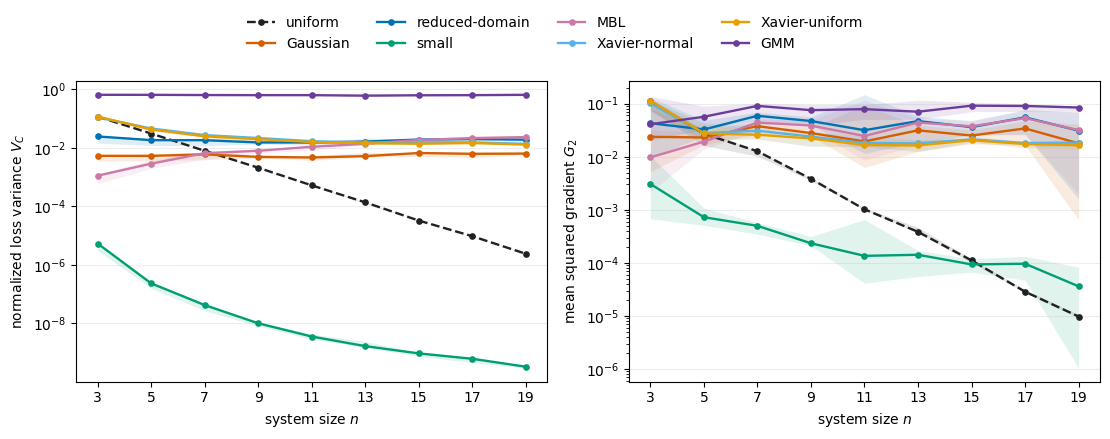

In [11]:
#| code-fold: true
#| code-summary: "Show scaling-figure code"
scaling_data = pd.read_csv("initialization_scaling_data_revised.csv")

method_order = [
    "uniform", "Gaussian", "reduced-domain", "small", "MBL",
    "Xavier-normal", "Xavier-uniform", "GMM",
]
colors = {
    "uniform": "#202124",
    "Gaussian": "#D55E00",
    "reduced-domain": "#0072B2",
    "small": "#009E73",
    "MBL": "#CC79A7",
    "Xavier-normal": "#56B4E9",
    "Xavier-uniform": "#E69F00",
    "GMM": "#6A3D9A",
}

summary = (
    scaling_data.groupby(["metric", "n", "method"])["value"]
    .agg(
        median="median",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        instances="count",
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
panels = [
    ("loss_variance", r"normalized loss variance $V_C$"),
    ("mean_squared_gradient", r"mean squared gradient $G_2$"),
]

for ax, (metric, ylabel) in zip(axes, panels):
    for method in method_order:
        subset = summary[(summary["metric"] == metric) & (summary["method"] == method)]
        if subset.empty:
            continue
        line_style = "--" if method == "uniform" else "-"
        ax.plot(
            subset["n"], subset["median"], marker="o", markersize=3.8,
            linewidth=1.7, linestyle=line_style, color=colors[method], label=method,
        )
        ax.fill_between(
            subset["n"], subset["q25"], subset["q75"],
            color=colors[method], alpha=0.12, linewidth=0,
        )
    ax.set_yscale("log")
    ax.set_xlabel(r"system size $n$")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(3, 20, 2))
    ax.grid(axis="y", alpha=0.22)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.savefig("initialization_scaling_revised.png", dpi=220, bbox_inches="tight")
plt.show()

The uniform baseline loses several orders of magnitude in both variande diagnostics as $n$ grows. GMM initialization retains the strongest signal in this benchmark, while Gaussian, reduced-domain, MBL, and both Xavier variants decay much more slowly than uniform sampling. The small-parameter scheme produces a particularly concentrated loss distribution and a comparatively small gradient moment. Its interval is deliberately conservative, and the dense SK observable plus mixed-axis circuit do not satisfy the local model used in the constant-gradient theorem.

The two panels also show why loss variance should not be used as the only trainability metric. A distribution can tightly concentrate the initial loss while still retaining a particular derivative, or it can preserve broad loss variation in directions that an optimizer does not exploit. Initialization must therefore be assessed with gradients or finite differences relevant to the actual optimization method.


### Impact of intitialization on optimization success

The second experiment fixes one $n=5$ SK instance and performs 100 exact state-vector optimization runs for every available initialization-optimizer pair, with a maximum of 1000 iterations. We report the approximation ratio

$$
q=\frac{C_{\mathrm{final}}-C_{\max}}{C_{\min}-C_{\max}},
$$

so that $q=1$ is the exact minimum and larger values are better. Points show the median over runs and bars show the interquartile range. The panel scales differ because the three optimizers reach very different accuracy regimes.


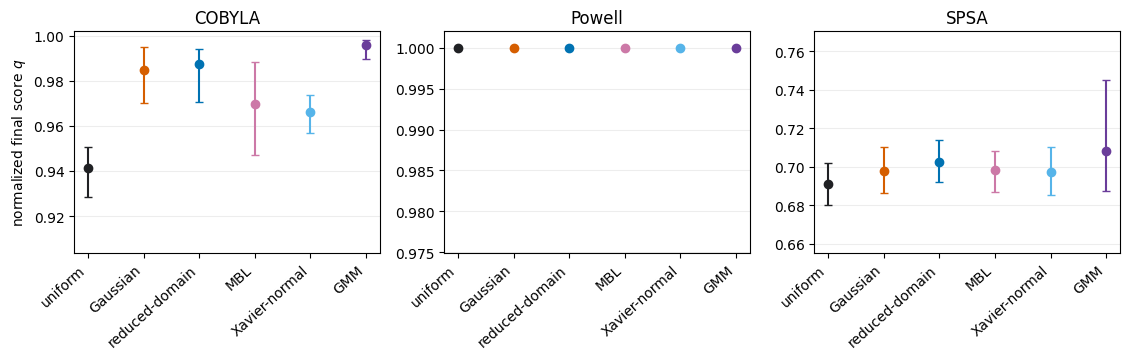

In [12]:
#| code-fold: true
#| code-summary: "Show optimization-comparison code"
optimization_data = pd.read_csv("initialization_optimization_data_revised.csv")
optimization_order = [
    "uniform", "Gaussian", "reduced-domain", "MBL", "Xavier-normal", "GMM",
]
optimizer_order = ["COBYLA", "Powell", "SPSA"]

opt_summary = (
    optimization_data.groupby(["optimizer", "init"])["normalized_final_score"]
    .agg(
        median="median",
        q25=lambda values: values.quantile(0.25),
        q75=lambda values: values.quantile(0.75),
        runs="count",
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(11.4, 3.7))
for ax, optimizer in zip(axes, optimizer_order):
    subset = opt_summary[opt_summary["optimizer"] == optimizer].set_index("init")
    subset = subset.reindex(optimization_order)
    x = np.arange(len(optimization_order))
    lower = subset["median"] - subset["q25"]
    upper = subset["q75"] - subset["median"]
    for position, method in enumerate(optimization_order):
        ax.errorbar(
            position, subset.loc[method, "median"],
            yerr=[[lower.loc[method]], [upper.loc[method]]],
            fmt="o", markersize=6, capsize=3, linewidth=1.5,
            color=colors[method],
        )
    ax.set_title(optimizer)
    ax.set_xticks(x, optimization_order, rotation=42, ha="right")
    ax.grid(axis="y", alpha=0.22)
    ax.set_ylim(
        max(0.0, float(subset["q25"].min()) - 0.025),
        min(1.002, float(subset["q75"].max()) + 0.025),
    )

axes[0].set_ylabel(r"normalized final score $q$")
fig.tight_layout()
fig.savefig("initialization_optimization_revised.png", dpi=220, bbox_inches="tight")
plt.show()

We see that the optimization results depend strongly on the classical optimizer. For COBYLA, GMM and the narrow near-identity schemes improve the final score relative to full-domain uniform sampling. Powell reaches nearly the same optimum from every tested distribution, leaving no room for initialization to matter. Under SPSA, only GMM shows a modest separation in the median, while most intervals overlap.

However, note that this experiment does not rank initialization methods universally, as it uses only one small problem instance, exact expectation values, and no hardware or sampling noise. But it does demonstrate the important logical distinction: **A larger initial landscape signal can make optimization possible, but it is not sufficient for better end-to-end trainability.** The optimizer, target Hamiltonian, ansatz expressibility, local minima, and the trajectory away from the initial region remain decisive.

## Summary

- Full-domain uniform initialization shows the expected exponential concentration as the system size grows.
- Gaussian and reduced-domain methods improve the starting region by shrinking parameter scales with depth.
- Small-parameter and MBL methods come with stronger structural assumptions; transferring them to another ansatz or observable requires care.
- Xavier initialization is a useful empirical baseline, but its quantum-circuit interpretation is heuristic.
- GMM initialization uses observable information and preserves the strongest initial signal in this diagonal-Ising benchmark.
- Initial loss or gradient statistics diagnose only the starting region. Optimization performance remains method-, optimizer-, and problem-dependent and must be assessed in larger-scale experiments.

Also note that estricting a circuit to a provably trainable region can also make its loss easier to simulate classically, so barren-plateau avoidance is not by itself evidence of a useful quantum advantage [@Cerezo.2025-DoesProvableAbsence]. A convincing initialization study should therefore report both initial signal and downstream performance, and it should state precisely when the assumptions of the underlying theorem match the circuit being tested.

## References

::: {#refs}
:::
